In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
parkinsons = fetch_ucirepo(id=174)

# data (as pandas dataframes)
X = parkinsons.data.features
y = parkinsons.data.targets
print(X.head())

# variable information
print(y.head())


   MDVP:Fo  MDVP:Fhi  MDVP:Flo  MDVP:Jitter  MDVP:Jitter  MDVP:RAP  MDVP:PPQ  \
0  119.992   157.302    74.997      0.00784      0.00784   0.00370   0.00554   
1  122.400   148.650   113.819      0.00968      0.00968   0.00465   0.00696   
2  116.682   131.111   111.555      0.01050      0.01050   0.00544   0.00781   
3  116.676   137.871   111.366      0.00997      0.00997   0.00502   0.00698   
4  116.014   141.781   110.655      0.01284      0.01284   0.00655   0.00908   

   Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer  ...  MDVP:APQ  Shimmer:DDA  \
0     0.01109       0.04374       0.04374  ...   0.02971      0.06545   
1     0.01394       0.06134       0.06134  ...   0.04368      0.09403   
2     0.01633       0.05233       0.05233  ...   0.03590      0.08270   
3     0.01505       0.05492       0.05492  ...   0.03772      0.08771   
4     0.01966       0.06425       0.06425  ...   0.04465      0.10470   

       NHR     HNR      RPDE       DFA   spread1   spread2        D2       PPE  

In [ ]:
print(X.info())
print(X.describe())
print(X.isnull().sum())
print(X.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MDVP:Fo       195 non-null    float64
 1   MDVP:Fhi      195 non-null    float64
 2   MDVP:Flo      195 non-null    float64
 3   MDVP:Jitter   195 non-null    float64
 4   MDVP:Jitter   195 non-null    float64
 5   MDVP:RAP      195 non-null    float64
 6   MDVP:PPQ      195 non-null    float64
 7   Jitter:DDP    195 non-null    float64
 8   MDVP:Shimmer  195 non-null    float64
 9   MDVP:Shimmer  195 non-null    float64
 10  Shimmer:APQ3  195 non-null    float64
 11  Shimmer:APQ5  195 non-null    float64
 12  MDVP:APQ      195 non-null    float64
 13  Shimmer:DDA   195 non-null    float64
 14  NHR           195 non-null    float64
 15  HNR           195 non-null    float64
 16  RPDE          195 non-null    float64
 17  DFA           195 non-null    float64
 18  spread1       195 non-null    

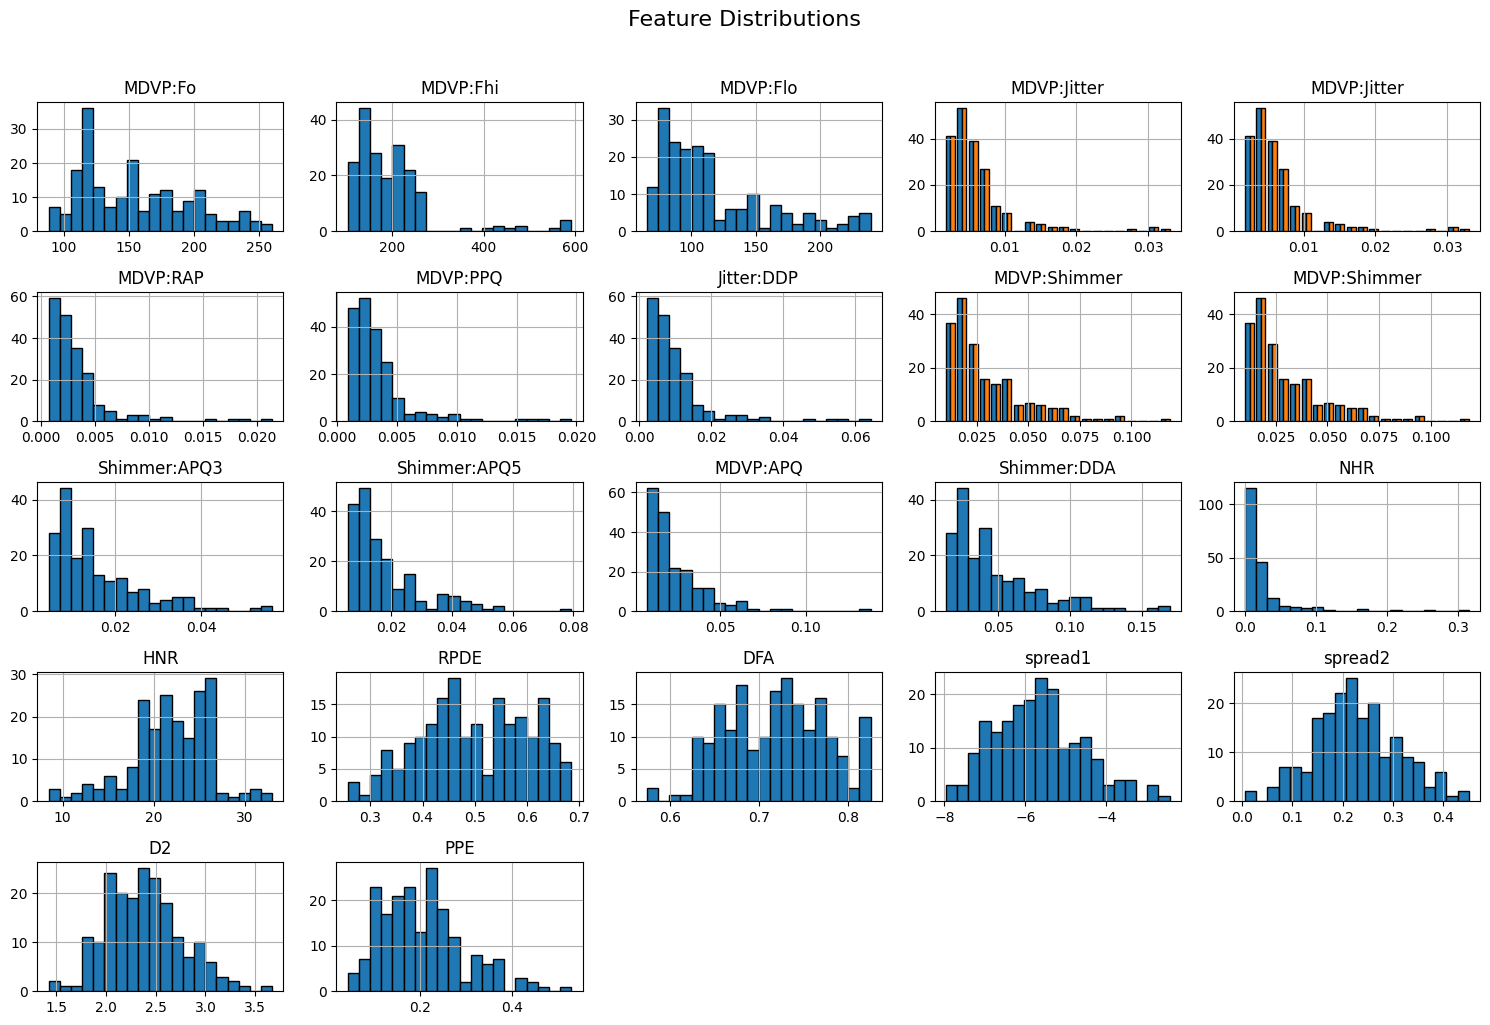

In [ ]:
import matplotlib.pyplot as plt

X.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
print(X_scaled)

[[-0.82929965 -0.43616456 -0.95203729 ...  0.48047686 -0.21053082
   0.86888575]
 [-0.77097169 -0.53097409 -0.05772056 ...  1.31118546  0.27507712
   1.80360503]
 [-0.90947638 -0.7231683  -0.10987483 ...  1.01768236 -0.10362861
   1.40266141]
 ...
 [ 0.49557839  0.47010361 -0.96839309 ... -0.81807931  0.78033848
  -0.83241014]
 [ 1.07876114  2.19004398 -0.95417967 ... -0.22906571 -0.63700298
  -0.92610456]
 [ 1.45481664  0.69224632 -0.88348115 ... -0.43085284  0.45480231
  -0.64505466]]


In [ ]:
import pandas as pd

# View scaled training data with column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

    MDVP:Fo  MDVP:Fhi  MDVP:Flo  MDVP:Jitter  MDVP:Jitter  MDVP:RAP  MDVP:PPQ  \
0 -0.829300 -0.436165 -0.952037     0.334914     0.334914  0.132963  0.760800   
1 -0.770972 -0.530974 -0.057721     0.715418     0.715418  0.453892  1.276809   
2 -0.909476 -0.723168 -0.109875     0.884991     0.884991  0.720770  1.585687   
3 -0.909622 -0.649092 -0.114229     0.775389     0.775389  0.578885  1.284076   
4 -0.925657 -0.606245 -0.130608     1.368893     1.368893  1.095750  2.047187   

   Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer  ...  MDVP:APQ  Shimmer:DDA  \
0    0.131755      0.745985      0.745985  ...  0.332985     0.607532   
1    0.452684      1.681731      1.681731  ...  1.159454     1.548254   
2    0.721813      1.202693      1.202693  ...  0.699187     1.175323   
3    0.577677      1.340396      1.340396  ...  0.806859     1.340229   
4    1.096793      1.836448      1.836448  ...  1.216839     1.899461   

        NHR       HNR      RPDE       DFA   spread1   spread2        D2  \

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (156, 22)
X_test shape: (39, 22)
y_train shape: (156, 1)
y_test shape: (39, 1)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

baseline_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree":       DecisionTreeClassifier(),
    "KNN":                 KNeighborsClassifier()
}

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("====== BASELINE MODELS ======\n")
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.2f}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.2f}")
    print(f"  F1 Score : {f1_score(y_test, y_pred):.2f}\n")

====== BASELINE MODELS ======

Logistic Regression
  Accuracy : 0.90
  Recall   : 1.00
  F1 Score : 0.94

Decision Tree
  Accuracy : 0.92
  Recall   : 0.97
  F1 Score : 0.95

KNN
  Accuracy : 0.95
  Recall   : 1.00
  F1 Score : 0.97



In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

better_models = {
    "SVM":                  SVC(),
    "Random Forest":        RandomForestClassifier(),
    "Gradient Boosting":    GradientBoostingClassifier(),
    "XGBoost":              XGBClassifier(random_state=42)
}

print("====== BETTER MODELS ======\n")
for name, model in better_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.2f}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.2f}")
    print(f"  F1 Score : {f1_score(y_test, y_pred):.2f}\n")

====== BETTER MODELS ======

SVM
  Accuracy : 0.90
  Recall   : 1.00
  F1 Score : 0.94

Random Forest
  Accuracy : 0.95
  Recall   : 1.00
  F1 Score : 0.97

Gradient Boosting
  Accuracy : 0.92
  Recall   : 0.97
  F1 Score : 0.95

XGBoost
  Accuracy : 0.95
  Recall   : 1.00
  F1 Score : 0.97



In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(XGBClassifier(random_state=42), params, cv=5, scoring='recall')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Recall:", grid.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best Recall: 0.9826086956521738
